# First attempt: MU muscle velocity control

In this Notebook, we want to simulate the control of an SMD operated by an SNN. The SMD models a motor unt (MU). Its state will be then coupled to two velocity component (vx, vy) of a muscle. The control target is not on the SMD states, but rather on these velocity components. Therefore, the network spikes based on the muscle target, influences the MU state, which as a consequence, changes the velocity of the muscle towards the target (hopefully). 

### Imports

We import numpy, scipy.linalg, pyplot, an rng from np.random, and our library for simulation.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
rng = np.random.default_rng()
import lib_sim
from importlib import reload
reload(lib_sim) 

<module 'lib_sim' from 'c:\\Users\\eilers\\Documents\\MU-recruitment-model\\2026---Obj4---MU-recruitment-model\\lib_sim.py'>

### Initializations
We initialize all the elements we need to run the simulations.


1. Number of Neurons *N*
2. Number of coupled neuromuscular units + the coordinates of the muscle they control (2, each with position and velocity)
2. **A** matrix. For a coupled oscillator system our state martix **A** will be slightly more complicated. We first fill the elements corresponding to the dynamics of each single unit, in a way that scales with our *M-1* units. Then, we fill in the cross terms that represent the effect of the state of a unit onto the states of the ones connected to it. Finally, we use the value *gamma* to represent the continuous cross terms which allow the state of the units to be associated with a point mass (muscle) which does not have the same oscillatory dynamics as the SMDs, but rather can be linearly controlled to change its velocity.
3. **B** matrix. In this case, we have to scale **B** according to the neurons *N* and the units *M*. We initialize it with random values and then we normalize those values by columns, so that each neuron has a comparable effect onto the system. No connection is present between our neurons and the muscle itself, so the first columns will be zeros.
4. **C** matrix. Cost martrix for state deviations. Also scaled based on *M*

In [2]:
N = 2 #neurons
M = 3 #For now, two muscle coordinates x and y (both with an uncontrolled position, and a velocity to control [vx,vy]) and one MUs state.

gamma_scale = 1

A = np.zeros((2*M, 2*M))


# Muscle equations stay the same: muscle is a non oscillatory x and y coordinate entity. Each coordinate of the muscle has a position and a velocity, one derivative of the other.
for i in range(M):
    A[2*i, 2*i+1] = 1 #velocities are derivatives of positions

# Remove self dynamics for first two masses (M) (muscle)
# (skip spring/damping for i=0,1)

# Normal SMDs for fibers (i >= 2) #we make them stiff for now, can be adjusted
omega = 1
rho = 1 # choose rho = 1 for critical damping or rho > 1 for overdamping (or rho < 1 for underdamping, which we don't want here)
for i in range(1, M):
    A[2*i+1, 2*i] = - omega**2
    A[2*i+1, 2*i+1] = - 2*rho*omega

# --- All fibers influence muscle, but they are now coupled with the muscle's velocities, not positions (to be checked). 
for j in range(1, M):
    vel_index = 2*j

    # alternating sign
    sign = (-1)**(j)

    A[1, vel_index] = -gamma_scale * sign

#B remains the same: the spikes only go into the SMDs anyway
B = np.zeros((2*M, N))
B_0 = 2

B[3, 0] = B_0
B[5, 1] = B_0

# Fill only even rows with random values
#for i in range(3, 2 * M, 2):
#    B[i] = np.random.randn(N)


# Normalize each column
#B /= np.linalg.norm(B, axis=0)
#for i in range(3, 2 * M, 2):
#    B[i] *= 6

#Cost matrix C is now 1 for the velocities (which now need to follow the target) and zero for positions

C = np.zeros((2*M, 2*M))
C[1, 1] = 1                        # was C[0, 0]: muscle velocity x

print(A)
print(B)
print(C)


[[ 0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0. -1.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0. -1. -2.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.]
 [ 0.  0.  0.  0. -1. -2.]]
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [2. 0.]
 [0. 0.]
 [0. 2.]]
[[0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


We also need to initialize all the other elements of the simulation: 

6. Time settings:
    - Number of seconds (T) timestep lenght (dt), time array, number of timesteps (nT)
    - Future time window $f$, here called *t_fut*
7. Target settings:
    - Here we want to set a target trajectory for each velocity coordinate of the arm. *z_base* is compiled to trace those trajectory. In the simulation, the target will iterate on the values of *z_base* over time.
8. Threshold parameters:
    - *mu*, spiking cost on the threshold (see math derivation)
    - If input delays from the system to the network are not considered, we simulate with asyncronous firing (one neuron is selected to spikes at a time). Optionally, we can take delays into consideration, which means allowing multiple neurons to fire in each timestep. To prevent overspiking in this case, we adjust the threshold based on previous spiking activity. The values of *a* and *lambda* scale this adjustments
    - refractory period *ref_period_lenght* is set to zero. The algorithm selects one neuron to fire in each timestep but does not impose any non-firing period. Since neurons fire to improve a future loss, they already tend to not overspike. We kept the option, so that the refractory period can be introduced if needed (for instance if delays are present)
9. Cell silencing parameters (optional):
    - *cell_death_timings* contains the timesteps in which we want to silence neurons
    - *k_per_step* manages how many neuron to silence in each of the silencing timetsep

In [ ]:
# Time settings
T = 100
dt = 1e-2
times = np.arange(0, T, dt)
nT = len(times)
t_fut = 10

# Target parameters
leak_z = 2
z = np.zeros((2*M, nT))
z_base = np.zeros((2*M, nT))  # same shape as z, only odd rows matter
f_base = np.zeros((2*M, nT))

# Set ramping target force
f_max = 2
f_base[1, int(nT/4):int(3*nT/4)] = np.linspace(0, f_max, int(3*nT/4) - int(nT/4))
f_base[1, int(3*nT/4):] = f_max

# Calculate the corresponding velocity target by integrating the force target over time
z_base[1, :] = np.cumsum(f_base[1,:]) * dt

# theta = 0.2
x = np.zeros((2*M, nT))
x0 = np.zeros((2*M))

#Threshold/firing parameters
lam = 0.3  #0.25
a = 0
mu = 0.3
ref_period_lenght = 0



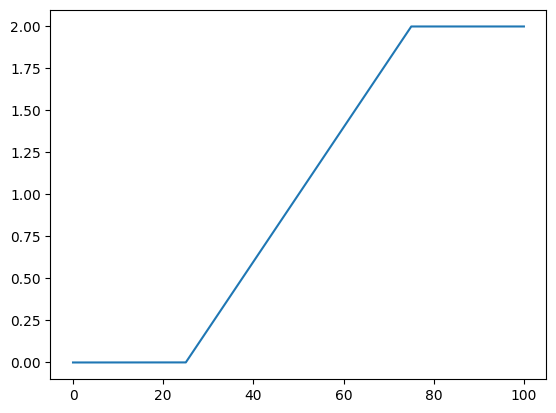

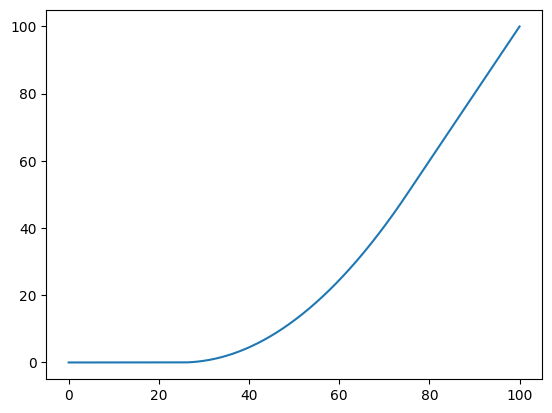

In [ ]:
# Plot target force and velocity
plt.plot(times, f_base[1, :], label='Force target')
plt.show()
plt.plot(times, z_base[1, :], label='Muscle velocity target')

### Simulation

We make use of the spiking control simulation function from lib_sim to simulate control of the SMDs and consequently the arm.

We extract:
- target z, 
- spikes s, 
- state x, 
- voltages V, 
- thresholds Th, 
- predicted state x_pred, 
- error E,  
- predicted error pE.


In [5]:
z, s, x, V, Th, x_pred, E, pE = lib_sim.simulate_coupled_spiking_control(nT, dt, t_fut, M, N, A, B, C, z.copy(), x.copy(), x0.copy(), lam, a, mu, ref_period_lenght, delay=False, kill=False, z_base=z_base, leak_z=leak_z)

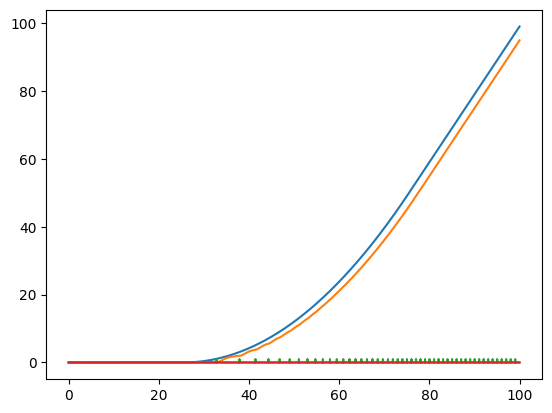

In [ ]:
# Comparison of speed target and actual speed

plt.plot(times, z[1, :], label='Muscle velocity target')
plt.plot(times, x[1,:], label='State')
plt.plot(times, s[0,:], label='Spikes')
plt.plot(times, s[1,:], label='Spikes')

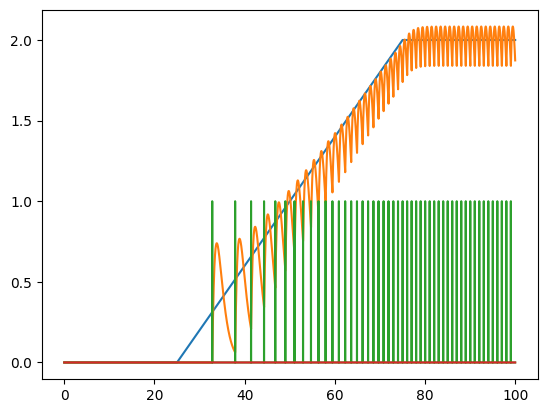

In [ ]:
# Comparison of force target and actual force output

plt.plot(times, f_base[1, :], label='Force target')
plt.plot(times, x[2,:] + x[4,:], label='Summed forces')
plt.plot(times, s[0,:], label='Spikes')
plt.plot(times, s[1,:], label='Spikes')

### Plotting Functions

We define ad-hoc function to 
- Plot the trajectories of the muscle velocity in 2D space (vx vs vy)
- Plot the SMD activity in the simulation
- Plot the raster plot for the SMD

In [53]:
def plot_musc_vel(x, z, hide=False, ax=None):
    # --- Target velocity trajectory ---
    ax.plot(z[1, :], z[3, :],
            color='gray',
            linewidth=1.5,
            label='Target velocity')
    # --- Actual muscle velocity trajectory ---
    ax.plot(x[1, :], x[3, :],
            color='indianred',
            linewidth=1.5,
            label='Arm velocity')
    ax.scatter(x[1, 0],  x[3, 0],  color='green', s=8, label='Start')
    ax.scatter(x[1, -1], x[3, -1], color='red',   s=8, label='End')
    # --- Labels ---
    ax.set_xlabel(r'$v_1$')
    ax.set_ylabel(r'$v_2$')
    if hide:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    ax.set_yticks(np.linspace(-20, 20, 3))
    ax.set_xticks(np.linspace(-20, 20, 3))

In [54]:
def plot_activity(x, z, E, times, xpred=None, incxpred=False, mus=False, timelabels=False, hide=False, ax=None):
    """
    Plots curves for even dimensions of x, z, and optionally x_pred.

    Parameters:
    - x: 2D or 3D array (shape=(n_dims, n_steps)), where rows are state variables (e.g., positions, velocities).
    - z: 2D or 3D array (shape=(n_dims, n_steps)), representing target curves.
    - E: 2D array (shape=(n_dims, n_steps)), error values for each dimension over time.
    - x_pred: 2D or 3D array (shape=(n_dims, n_steps)), predicted curves (optional).
    - times: 1D array of time points.
    - incxpred: Boolean, whether to include x_pred curves in the plot.
    """
    # Determine the even dimensions
    #even_dims = [i for i in range(x.shape[0]) if i % 2 == 0]
    odd_dims = range(1, x.shape[0], 2)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the target curves (z) for the even dimensions
    for i in odd_dims:
        if mus==False:
            ax.plot(times, z[i, :], linewidth=1.5, alpha=0.8, color='grey')
            ax.plot(times, x[i, :], linewidth=1.5, color='indianred')
        else:
            ax.plot(times, x[i, :], linewidth=1.5, alpha=0.6, color='purple')
        
        
    # Plot the predicted curves (x_pred) if xpred is True
    if incxpred is True and xpred is not None:
        for i in odd_dims:
            ax.plot(times, xpred[i, :], linestyle=':', linewidth=1.5)
    
    # # Plot the summed error across even dimensions
    # summed_error = np.sum(E[odd_dims, :], axis=0)  # Sum error across even dimensions

    # if mus==False:
    #     ax.plot(times, summed_error, linewidth=1.5, color='blue', label='Summed Error')
    # else:
    #     ax.plot(times, E[0, :], linewidth=1.5, color='blue', label='Summed Error')


    #ax.plot(times,  U[0], label=f'Spikes', linewidth=1.5, alpha=0.5, color='lightblue')

    # Add labels, legend
    ax.set_xlabel('')
    ax.set_xticks(np.linspace(0, times[-1], 6), ['']*6)
    ax.set_xlim(left=times[0])
    ax.set_xlim(right=times[-1])
    ax.set_ylabel('Value')

    if timelabels:
        ax.set_xticks(np.linspace(0, times[-1], 6))
        ax.set_xlabel('Time')
    else:
        ax.set_xticks(np.linspace(0, times[-1], 6), ['']*6)
        ax.set_xlim(left=times[0])
        ax.set_xlim(right=times[-1])

In [55]:
def coupled_raster_plot(s, times, silence=False, hide=False, ax=None, **kwargs):
    """
    Plots a raster plot of spikes.

    Parameters:
    - s: Spike matrix (N x T), where N is the number of neurons and T is the number of timesteps.
    - times: Time array for the x-axis.
    - ax: Matplotlib axis object to plot on. If None, creates a new figure and axis.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Loop through each neuron
    for neuron_id in range(s.shape[0]):
        # Find spike times
        spike_times = times[s[neuron_id, :] == 1]
        # Plot the spikes for this neuron
        ax.scatter(spike_times, [neuron_id] * len(spike_times), s=0.5, color='black', alpha=1)

    if hide:
        ax.set_ylabel('Neurons', labelpad= 15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if silence:
        cell_death_timings = kwargs['cell_death_timings']
        k_per_step = kwargs['k_per_step']
        N = kwargs['N']

        t1 = ((cell_death_timings[0]/100)+0.4)
        # Second vertical line
        t2 = ((cell_death_timings[1]/100)+0.4)
        ax.plot([t1, t1], [N, N - (k_per_step-2)], color='red', linestyle='-', linewidth=1.3)
        ax.plot([t2, t2], [N - k_per_step, (N - k_per_step) - (k_per_step-2)], color='red', linestyle='-', linewidth=1.3)

    # Add labels, ticks etc
    ax.invert_yaxis()
    ax.set_ylabel('Neurons', labelpad= 14)
    #ax.set_yticks([])
    ax.set_xlabel('Time')
    ax.set_xticks(np.linspace(0, times[-1], 6))
    ax.set_xlim(times[0], times[-1])
    ax.margins(x=0.5)

### Plotting 

Now we use the functions we created along wit the ones in our lib_plot library to plot all the individual axes of the figure.

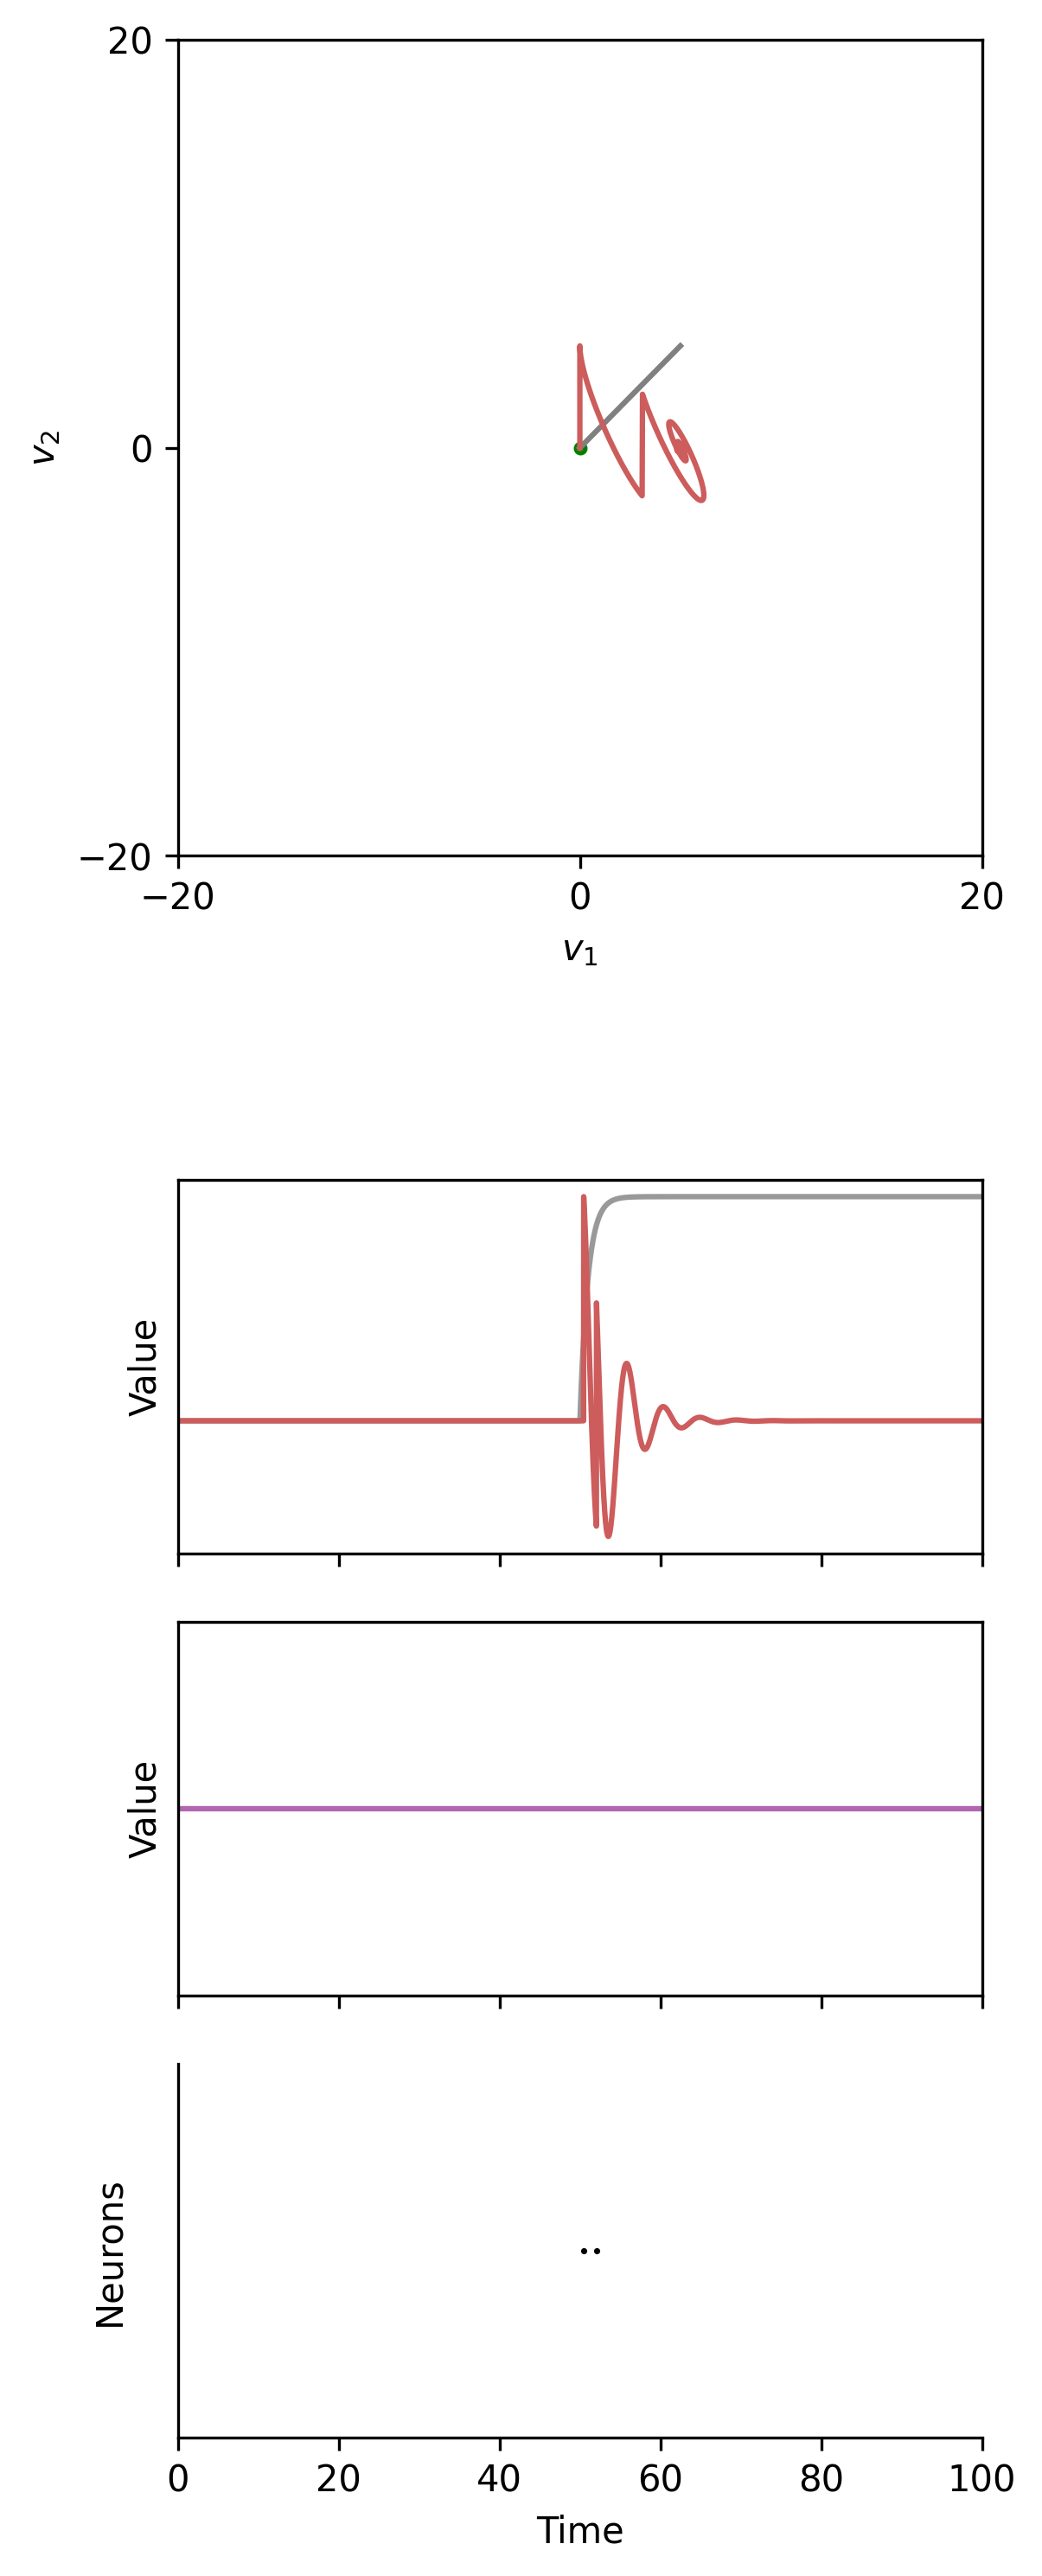

In [56]:
#AxsC
plot_mosaic = [['A', 'A'],
               ['A', 'A'],
               ['.', '.'],
               ['B', 'B'],
               ['Bi', 'Bi'],
               ['Bii', 'Bii'],
]


#Generate figure and axes
fig, axs = plt.subplot_mosaic( 
        plot_mosaic, 
        #layout='constrained', 
        #empty_sentinel=None,
        figsize=(4, 12), 
        dpi=300,
        gridspec_kw={'height_ratios': [1, 1, 0.5, 1, 1, 1], 'width_ratios': [1, 1]}

)

fig.set_constrained_layout_pads(hspace=0.01)
for label, ax in axs.items():
    if label != '.':  # Skip spacers
        ax.plot()  
        ax.set_xticks([])
        ax.set_yticks([])  

odd_idx_mus = np.arange(1, 4, 2)
x_es_mus = x[odd_idx_mus, :] 
z_es_mus  = z[odd_idx_mus, :]

x_es_smd  = x[4:, :]
z_es_smd = z[3:, :]
s_es_smd  = s

plot_musc_vel(x, z, hide=False, ax=axs['A'])

plot_activity(x_es_mus, z_es_mus, E, times, xpred=None, incxpred=False, mus=False, timelabels=False, hide=True, ax=axs['B'])

plot_activity(x_es_smd, z_es_smd, E*0, times, xpred=None, incxpred=False, mus=True, timelabels=False, hide=True, ax=axs['Bi'])

coupled_raster_plot(s_es_smd, times, slence=True, hide=True, ax=axs['Bii'], N=N)
plt.plot()
plt.show()
